In [828]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import re

In [829]:
# 1. Global charging stations
global_stations = pd.read_csv('../Data/charging_station.csv')
global_stations.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
0,307660,Av. de Tarragona,Andorra,UNKNOWN,AD,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),True
1,301207,Parquing Costa Rodona,Encamp,UNKNOWN,AD,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),False
2,301206,Hotel Naudi,Unknown City,UNKNOWN,AD,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),False
3,301205,Hotel Piolets Soldeu Centre,Unknown City,UNKNOWN,AD,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),False
4,301204,Hotel Serras,Unknown City,UNKNOWN,AD,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),False


In [830]:
global_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242417 entries, 0 to 242416
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              242417 non-null  int64  
 1   name            242417 non-null  object 
 2   city            242417 non-null  object 
 3   state_province  242417 non-null  object 
 4   country_code    242417 non-null  object 
 5   latitude        242417 non-null  float64
 6   longitude       242417 non-null  float64
 7   ports           242417 non-null  int64  
 8   power_kw        237757 non-null  float64
 9   power_class     242417 non-null  object 
 10  is_fast_dc      242417 non-null  bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 18.7+ MB


In [831]:
global_stations['country_code'].unique()

array(['AD', 'AE', 'AF', 'AL', 'AM', 'AR', 'AT', 'AU', 'AX', 'AZ', 'BA',
       'BB', 'BE', 'BG', 'BH', 'BR', 'BW', 'BY', 'CA', 'CH', 'CL', 'CN',
       'CO', 'CR', 'CY', 'CZ', 'DE', 'DK', 'DO', 'EC', 'EE', 'EG', 'ES',
       'ET', 'FI', 'FO', 'FR', 'GB', 'GE', 'GG', 'GH', 'GI', 'GR', 'GT',
       'HK', 'HR', 'HU', 'ID', 'IE', 'IL', 'IM', 'IN', 'IQ', 'IS', 'IT',
       'JE', 'JM', 'JO', 'JP', 'KE', 'KG', 'KH', 'KR', 'KZ', 'LI', 'LK',
       'LT', 'LU', 'LV', 'MA', 'MC', 'MD', 'ME', 'MK', 'MM', 'MO', 'MT',
       'MX', 'MY', 'NAM', 'NL', 'NO', 'NP', 'NZ', 'OM', 'PA', 'PE', 'PH',
       'PK', 'PL', 'PR', 'PS', 'PT', 'PY', 'QA', 'RE', 'RO', 'RS', 'RU',
       'RW', 'SA', 'SE', 'SG', 'SI', 'SJ', 'SK', 'SM', 'SZ', 'TH', 'TN',
       'TR', 'TT', 'TW', 'UA', 'UG', 'US', 'UY', 'UZ', 'VN', 'XK', 'ZA'],
      dtype=object)

In [832]:
kenya_global = global_stations[global_stations['country_code'] == 'KE']
kenya_global

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False
128400,189880,Nopea JKIA Airport,Nairobi,Nairobi,KE,-1.333731,36.928334,1,22.0,AC_HIGH_(22-49kW),False
128401,175802,Two Rivers Mall Nairobi (Nopea),Nairobi,Nairobi,KE,-1.211449,36.795808,1,11.0,AC_L2_(7.5-21kW),False
128402,175801,Sarit Centre Nairobi,Nairobi,Nairobi,KE,-1.261245,36.802243,1,22.0,AC_HIGH_(22-49kW),False
128403,175800,TRM Mall,Nairobi,Nairobi,KE,-1.219824,36.889224,2,22.0,AC_HIGH_(22-49kW),False
128404,175799,Holy Family Basilica Parking Silo,Nairobi,Nairobi,KE,-1.287358,36.820061,1,11.0,AC_L2_(7.5-21kW),False


In [833]:
kenya_global.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12 entries, 128395 to 128406
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              12 non-null     int64  
 1   name            12 non-null     object 
 2   city            12 non-null     object 
 3   state_province  12 non-null     object 
 4   country_code    12 non-null     object 
 5   latitude        12 non-null     float64
 6   longitude       12 non-null     float64
 7   ports           12 non-null     int64  
 8   power_kw        12 non-null     float64
 9   power_class     12 non-null     object 
 10  is_fast_dc      12 non-null     bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 1.0+ KB


In [834]:
# 2. Kenyan EV charging stations sample
kenya_stations_sample = pd.read_csv('../Data/kenya_ev_charging_stations_sample_new.csv')
kenya_stations_sample.head()

,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790


In [835]:
kenya_stations_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   County/City      16 non-null     object 
 1   Station Name     16 non-null     object 
 2   Charger Type     16 non-null     object 
 3   Connector Types  16 non-null     object 
 4   Latitude         16 non-null     float64
 5   Longitude        16 non-null     float64
dtypes: float64(2), object(4)
memory usage: 896.0+ bytes


In [836]:
# 3. Kenya Population census data
population = pd.read_csv('../Data/kenya-population-distibution-2019-census.csv')
population.head()

,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1


In [837]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   County    48 non-null     object
 1   Total     48 non-null     object
 2   Male      48 non-null     object
 3   Female    48 non-null     object
 4   Intersex  48 non-null     object
dtypes: object(5)
memory usage: 2.0+ KB


In [838]:
admin_boundaries = pd.read_excel("../Data/ken_adminboundaries_tabulardata.xlsx")
admin_boundaries.head()

,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [839]:
admin_boundaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OBJECTID *         290 non-null    int64         
 1   Shape *            290 non-null    object        
 2   admin2Name_en      290 non-null    object        
 3   admin2Pcode        290 non-null    object        
 4   admin2RefName      290 non-null    object        
 5   admin2AltName1_en  290 non-null    object        
 6   admin2AltName2_en  290 non-null    object        
 7   admin1Name_en      290 non-null    object        
 8   admin1Pcode        290 non-null    object        
 9   admin0Name_en      290 non-null    object        
 10  admin0Pcode        290 non-null    object        
 11  date               290 non-null    datetime64[ns]
 12  validOn            290 non-null    datetime64[ns]
 13  validTo            290 non-null    object        
 14  Shape_Leng

In [840]:
county_coords = pd.read_csv("../Data/county_coordinates.csv")
county_coords.head()

,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.283300
1,Kericho,-0.367740,35.283140
2,Nandi,0.166667,35.150000
3,Siaya,-0.083333,34.249999
4,Nakuru,-0.283332,36.066666


In [841]:
county_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   county     47 non-null     object 
 1   Latitude   47 non-null     float64
 2   Longitude  47 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


### Data Cleaning

In [842]:
kenya_global.duplicated().sum()

0

In [843]:
kenya_global.isnull().sum()

id                0
name              0
city              0
state_province    0
country_code      0
latitude          0
longitude         0
ports             0
power_kw          0
power_class       0
is_fast_dc        0
dtype: int64

In [844]:
kenya_stations_sample.duplicated().sum()

0

In [845]:
kenya_stations_sample.isnull().sum()

County/City        0
Station Name       0
Charger Type       0
Connector Types    0
Latitude           0
Longitude          0
dtype: int64

In [846]:
population.duplicated().sum()

0

In [847]:
population.isnull().sum()

County      0
Total       0
Male        0
Female      0
Intersex    0
dtype: int64

In [848]:
admin_boundaries.duplicated().sum()

0

In [849]:
admin_boundaries.isnull().sum()

OBJECTID *           0
Shape *              0
admin2Name_en        0
admin2Pcode          0
admin2RefName        0
admin2AltName1_en    0
admin2AltName2_en    0
admin1Name_en        0
admin1Pcode          0
admin0Name_en        0
admin0Pcode          0
date                 0
validOn              0
validTo              0
Shape_Length         0
Shape_Area           0
dtype: int64

In [850]:
county_coords.duplicated().sum()

0

In [851]:
county_coords.isnull().sum()

county       0
Latitude     0
Longitude    0
dtype: int64

### Data preparation

In [852]:
kenya_global.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False


In [853]:
kenya_global = kenya_global.drop(columns=['id', 'city', 'is_fast_dc'])
kenya_global.head()

,name,state_province,country_code,latitude,longitude,ports,power_kw,power_class
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW)
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW)
128397,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW)
128398,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW)
128399,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW)


In [854]:
kenya_global = kenya_global.rename(columns={"state_province": "county", "name": "station name"})

In [855]:
kenya_global['county'].value_counts()

Nairobi    11
Mombasa     1
Name: county, dtype: int64

In [856]:
kenya_global["charger type"] = kenya_global["power_class"].str.split("_").str[0].str.upper()

In [857]:
kenya_global = kenya_global.drop(columns = ["power_class", "power_kw"])

In [858]:
kenya_global.head(2)

,station name,county,country_code,latitude,longitude,ports,charger type
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,AC
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,AC


In [859]:
kenya_stations_sample.head()

,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790


In [860]:
kenya_stations_sample =kenya_stations_sample.drop(columns='Connector Types')

In [861]:
kenya_stations_sample = kenya_stations_sample.rename(columns={"County/City": "county", "Station Name": "station name", "Charger Type": "charger type", "Latitude": "latitude", "Longitude": "longitude"})

In [862]:
kenya_stations_sample['county'].value_counts()

Nairobi     9
Kiambu      1
Kisumu      1
Mombasa     1
Narok       1
Nakuru      1
Naivasha    1
Mavoko      1
Name: county, dtype: int64

In [863]:
kenya_stations_sample['county'] = kenya_stations_sample['county'].replace(['Mavoko', 'Naivasha'], ['Machakos', 'Nakuru'])

In [864]:
kenya_stations_sample['county'].value_counts()

Nairobi     9
Nakuru      2
Kiambu      1
Kisumu      1
Machakos    1
Mombasa     1
Narok       1
Name: county, dtype: int64

In [865]:
kenya_stations_sample.head(2)

,county,station name,charger type,latitude,longitude
0,Nairobi,Sarit Centre,AC + DC,-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,-1.210229,36.795216


In [866]:
population

,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1
5,Lamu,"38,446","19,533","18,911",2
6,Taita/Taveta,"93,774","46,620","47,149",5
7,Garissa,"210,890","109,552","101,331",7
8,Wajir,"177,174","94,812","82,340",22
9,Mandera,"270,467","135,548","134,909",10


In [867]:
population = population.drop(columns=['Male', 'Female', 'Intersex'])

In [868]:
population = population.rename(columns={"County": "county", "Total": "population"})

In [869]:
population = population[population['county'] != 'KENYA']

In [870]:
population['county'] = population['county'].replace(['Nairobi City', 'Elg eyo/Marakwet', 'Taita/Taveta'], ['Nairobi', 'Elgeyo-Marakwet', 'Taita Taveta'])

In [871]:
population['population'] = population['population'].str.replace(',', '').astype(int)

In [872]:
population.head(2)

,county,population
1,Mombasa,1208333
2,Kwale,126431


In [873]:
admin_boundaries.head()

,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [874]:
admin_boundaries = admin_boundaries.rename(columns={"admin1Name_en": "county","admin2Name_en": "sub county", "admin0Pcode": "country code", "Shape_Area": "shape area", "Shape_Length": "shape length"})

In [875]:
admin_boundaries = admin_boundaries[['county', 'sub county', 'country code', 'shape area', 'shape length']]

In [876]:
admin_boundaries

,county,sub county,country code,shape area,shape length
0,Uasin Gishu,Ainabkoi,KE,0.040829,1.746986
1,Kericho,Ainamoi,KE,0.019957,0.917307
2,Nandi,Aldai,KE,0.038000,1.402637
3,Siaya,Alego Usonga,KE,0.049357,1.081354
4,Migori,Awendo,KE,0.021365,0.743915
...,...,...,...,...,...
285,Bungoma,Webuye West,KE,0.019180,1.010876
286,Nyamira,West Mugirango,KE,0.014610,0.630183
287,Nairobi,Westlands,KE,0.005908,0.405298
288,Taita Taveta,Wundanyi,KE,0.069243,1.214526


In [877]:
county_coords.head(2)

,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


In [878]:
county_coords = county_coords.rename(columns={"Latitude": "county_lat", "Longitude": "county_lon"})

In [879]:
county_coords.head(2)

,county,county_lat,county_lon
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


merging all the stations from kenyaglobal and from kenya sations together

In [880]:
kenya_global.head(2)

,station name,county,country_code,latitude,longitude,ports,charger type
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,AC
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,AC


In [881]:
kenya_stations_sample.head(2)

,county,station name,charger type,latitude,longitude
0,Nairobi,Sarit Centre,AC + DC,-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,-1.210229,36.795216


In [882]:
# Combine all rows from both dataframes
kenya_stations = pd.concat([kenya_global, kenya_stations_sample], ignore_index=True)
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [883]:
kenya_stations = kenya_stations.drop(index=[12, 13, 14, 25])
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [884]:
kenya_stations.isnull().sum()

station name     0
county           0
country_code    12
latitude         0
longitude        0
ports           12
charger type     0
dtype: int64

In [885]:
kenya_stations['country_code'] = kenya_stations['country_code'].fillna('KE')

In [886]:
kenya_stations['ports'] = kenya_stations['ports'].fillna(1.0)

In [887]:
kenya_stations.isnull().sum()

station name    0
county          0
country_code    0
latitude        0
longitude       0
ports           0
charger type    0
dtype: int64

In [888]:
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [889]:
station_counts = kenya_stations.groupby('county').size().reset_index(name='num_stations')
station_counts

,county,num_stations
0,Kiambu,1
1,Kisumu,1
2,Machakos,1
3,Mombasa,1
4,Nairobi,17
5,Nakuru,2
6,Narok,1


merging population and station data

In [890]:
county_df = county_coords.merge(population, on='county', how='left')
county_df.head()

,county,county_lat,county_lon,population
0,Uasin Gishu,0.516667,35.283300,510205
1,Kericho,-0.367740,35.283140,93538
2,Nandi,0.166667,35.150000,59479
3,Siaya,-0.083333,34.249999,85417
4,Nakuru,-0.283332,36.066666,1047080


In [891]:
county_df = county_df.merge(station_counts, on='county', how='left')
county_df.head()

,county,county_lat,county_lon,population,num_stations
0,Uasin Gishu,0.516667,35.283300,510205,NaN
1,Kericho,-0.367740,35.283140,93538,NaN
2,Nandi,0.166667,35.150000,59479,NaN
3,Siaya,-0.083333,34.249999,85417,NaN
4,Nakuru,-0.283332,36.066666,1047080,2.0


In [892]:
county_df['num_stations'] = county_df['num_stations'].fillna(0)

In [893]:
county_df.head(15)

,county,county_lat,county_lon,population,num_stations
0,Uasin Gishu,0.516667,35.283300,510205,0.0
1,Kericho,-0.367740,35.283140,93538,0.0
2,Nandi,0.166667,35.150000,59479,0.0
3,Siaya,-0.083333,34.249999,85417,0.0
4,Nakuru,-0.283332,36.066666,1047080,2.0
5,Garissa,-0.452750,39.646010,210890,0.0
6,Mandera,3.416670,40.666700,270467,0.0
7,Baringo,0.466670,35.966670,75289,0.0
8,Kisii,-0.681740,34.766660,151410,0.0
9,Bomet,-0.800000,35.233300,27971,0.0


In [894]:
# Rebuild county area properly
county_area = (admin_boundaries.groupby("county", as_index=False)["shape area"].sum())
county_area.head()

,county,shape area
0,Baringo,0.884732
1,Bomet,0.198098
2,Bungoma,0.245060
3,Busia,0.147178
4,Elgeyo-Marakwet,0.244432


In [895]:
county_df = county_df.merge(county_area[['county', 'shape area']], on='county', how='left')
county_df.head()

,county,county_lat,county_lon,population,num_stations,shape area
0,Uasin Gishu,0.516667,35.283300,510205,0.0,0.275976
1,Kericho,-0.367740,35.283140,93538,0.0,0.204180
2,Nandi,0.166667,35.150000,59479,0.0,0.230383
3,Siaya,-0.083333,34.249999,85417,0.0,0.286003
4,Nakuru,-0.283332,36.066666,1047080,2.0,1.283619


### Feature Engineering

In [896]:
county_df['stations_per_100k'] = (county_df['num_stations'] / county_df['population']) * 100000
county_df.head()

,county,county_lat,county_lon,population,num_stations,shape area,stations_per_100k
0,Uasin Gishu,0.516667,35.283300,510205,0.0,0.275976,0.000000
1,Kericho,-0.367740,35.283140,93538,0.0,0.204180,0.000000
2,Nandi,0.166667,35.150000,59479,0.0,0.230383,0.000000
3,Siaya,-0.083333,34.249999,85417,0.0,0.286003,0.000000
4,Nakuru,-0.283332,36.066666,1047080,2.0,1.283619,0.191007


In [897]:
county_df['population_density'] = (county_df['population'] / county_df['shape area'])
county_df.head()

,county,county_lat,county_lon,population,num_stations,shape area,stations_per_100k,population_density
0,Uasin Gishu,0.516667,35.283300,510205,0.0,0.275976,0.000000,1.848730e+06
1,Kericho,-0.367740,35.283140,93538,0.0,0.204180,0.000000,4.581154e+05
2,Nandi,0.166667,35.150000,59479,0.0,0.230383,0.000000,2.581744e+05
3,Siaya,-0.083333,34.249999,85417,0.0,0.286003,0.000000,2.986577e+05
4,Nakuru,-0.283332,36.066666,1047080,2.0,1.283619,0.191007,8.157249e+05


In [898]:
# if zero stations use population as the value to avoid division by zero
county_df["population_per_station"] = np.where(
    county_df["num_stations"] > 0,
    county_df["population"] / county_df["num_stations"],
    county_df["population"]
)

In [899]:
# concentration_of_stations
county_df["station_spatial_density"] = (county_df["num_stations"] / county_df["shape area"])
county_df.head()

,county,county_lat,county_lon,population,num_stations,shape area,stations_per_100k,population_density,population_per_station,station_spatial_density
0,Uasin Gishu,0.516667,35.283300,510205,0.0,0.275976,0.000000,1.848730e+06,510205.0,0.000000
1,Kericho,-0.367740,35.283140,93538,0.0,0.204180,0.000000,4.581154e+05,93538.0,0.000000
2,Nandi,0.166667,35.150000,59479,0.0,0.230383,0.000000,2.581744e+05,59479.0,0.000000
3,Siaya,-0.083333,34.249999,85417,0.0,0.286003,0.000000,2.986577e+05,85417.0,0.000000
4,Nakuru,-0.283332,36.066666,1047080,2.0,1.283619,0.191007,8.157249e+05,523540.0,1.558095


In [900]:
county_df["required_stations"] = np.ceil(county_df["population"] / 200000)

# Ensure minimum 1 per county
county_df["required_stations"] = county_df["required_stations"].apply(lambda x: max(1, x)).astype(int)

In [901]:
county_df["additional_stations"] = (
    county_df["required_stations"] - county_df["num_stations"]
)

county_df["additional_stations"] = county_df["additional_stations"].apply(lambda x: max(0, x)).astype(int)
county_df

,county,county_lat,county_lon,population,num_stations,shape area,stations_per_100k,population_density,population_per_station,station_spatial_density,required_stations,additional_stations
0,Uasin Gishu,0.516667,35.283300,510205,0.0,0.275976,0.000000,1.848730e+06,5.102050e+05,0.000000,3,3
1,Kericho,-0.367740,35.283140,93538,0.0,0.204180,0.000000,4.581154e+05,9.353800e+04,0.000000,1,1
2,Nandi,0.166667,35.150000,59479,0.0,0.230383,0.000000,2.581744e+05,5.947900e+04,0.000000,1,1
3,Siaya,-0.083333,34.249999,85417,0.0,0.286003,0.000000,2.986577e+05,8.541700e+04,0.000000,1,1
4,Nakuru,-0.283332,36.066666,1047080,2.0,1.283619,0.191007,8.157249e+05,5.235400e+05,1.558095,6,4
5,Garissa,-0.452750,39.646010,210890,0.0,3.542187,0.000000,5.953666e+04,2.108900e+05,0.000000,2,2
6,Mandera,3.416670,40.666700,270467,0.0,2.114345,0.000000,1.279200e+05,2.704670e+05,0.000000,2,2
7,Baringo,0.466670,35.966670,75289,0.0,0.884732,0.000000,8.509809e+04,7.528900e+04,0.000000,1,1
8,Kisii,-0.681740,34.766660,151410,0.0,0.106738,0.000000,1.418520e+06,1.514100e+05,0.000000,1,1
9,Bomet,-0.800000,35.233300,27971,0.0,0.198098,0.000000,1.411978e+05,2.797100e+04,0.000000,1,1


### Modeling and Evaluation

predicting required stations so that we can:
1. generalize for future populaton growth
2. stop usig the specific defined policy and let model find patterns.

In [902]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "population",
    "population_density",
    "population_per_station",
    "station_spatial_density"
]

X = county_df[features]
y = county_df["required_stations"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [903]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [904]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

print("accuracy:", model.score(X_test, y_test))

MAE: 0.656
R2: 0.6709875173370319
accuracy: 0.6709875173370319


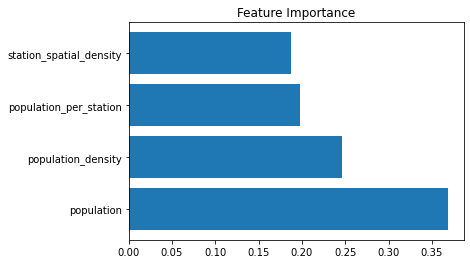

In [905]:
importance = model.feature_importances_

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

predicting new station locations (simple kmeans)

In [906]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# Store all new suggested stations here
new_station_locations = []

for index, county in county_df.iterrows():
    
    county_name = county["county"]
    k = int(county["additional_stations"])
    
    if k <= 0:
        continue  # No new stations needed
    
    county_stations = kenya_stations[kenya_stations["county"] == county_name]
    
    # -------------------------------------
    # CASE 1: County already has stations
    # -------------------------------------
    if len(county_stations) > 0:
        
        existing_coords = county_stations[["latitude", "longitude"]].values
        
        # If existing stations < k, we cluster using existing ones
        # Otherwise cluster normally
        
        if len(existing_coords) >= k:
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(existing_coords)
            centers = kmeans.cluster_centers_
        else:
            # If fewer existing points than k,
            # we duplicate some points slightly to allow clustering
            expanded_coords = existing_coords
            while len(expanded_coords) < k:
                expanded_coords = np.vstack([
                    expanded_coords,
                    existing_coords + np.random.uniform(-0.01, 0.01, existing_coords.shape)
                ])
            
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(expanded_coords)
            centers = kmeans.cluster_centers_
        
        for center in centers:
            new_station_locations.append({
                "county": county_name,
                "latitude": center[0],
                "longitude": center[1]
            })
    
    # -------------------------------------
    # CASE 2: County has NO stations
    # -------------------------------------
    else:
        
        county_lat = county["county_lat"]
        county_lon = county["county_lon"]
        
        for i in range(k):
            new_station_locations.append({
                "county": county_name,
                "latitude": county_lat + np.random.uniform(-0.05, 0.05),
                "longitude": county_lon + np.random.uniform(-0.05, 0.05)
            })

# Convert to dataframe
new_stations_df = pd.DataFrame(new_station_locations)

In [907]:
new_stations_df

,county,latitude,longitude
0,Uasin Gishu,0.505085,35.291812
1,Uasin Gishu,0.539187,35.296840
2,Uasin Gishu,0.538079,35.276215
3,Kericho,-0.344977,35.247514
4,Nandi,0.132926,35.116283
...,...,...,...
70,Tharaka-Nithi,-0.301332,38.019808
71,Machakos,-1.430895,36.953392
72,Machakos,-1.428810,36.960870
73,Samburu,1.165555,36.668856


#### CASE 1 : Counties with existing stations and existing ≥ additional

In [908]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

new_locations_case1 = []

case1 = county_df[
    (county_df["num_stations"] > 0) &
    (county_df["num_stations"] >= county_df["additional_stations"]) &
    (county_df["additional_stations"] > 0)
]

for _, county in case1.iterrows():
    
    county_name = county["county"]
    k = int(county["additional_stations"])
    
    county_stations = kenya_stations[kenya_stations["county"] == county_name]
    existing_coords = county_stations[["latitude", "longitude"]].values
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(existing_coords)
    centers = kmeans.cluster_centers_
    
    for center in centers:
        new_locations_case1.append({
            "county": county_name,
            "latitude": center[0],
            "longitude": center[1]
        })

case1_df = pd.DataFrame(new_locations_case1)

#### CASE 2 : Counties with existing stations but existing < additional

In [909]:
new_locations_case2 = []

case2 = county_df[
    (county_df["num_stations"] > 0) &
    (county_df["num_stations"] < county_df["additional_stations"])
]

for _, county in case2.iterrows():
    
    county_name = county["county"]
    k = int(county["additional_stations"])
    area = county["shape area"]
    
    county_stations = kenya_stations[kenya_stations["county"] == county_name]
    existing_coords = county_stations[["latitude", "longitude"]].values
    
    expanded_coords = existing_coords.copy()

    radius = np.sqrt(area) * 0.5
    
    while len(expanded_coords) < k:
        angle = np.random.uniform(0, 2*np.pi)
        r = radius * np.sqrt(np.random.uniform(0,1))
        new_lat = county["county_lat"] + r * np.cos(angle)
        new_lon = county["county_lon"] + r * np.sin(angle)
        expanded_coords = np.vstack([expanded_coords, [[new_lat, new_lon]]])
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(expanded_coords)
    centers = kmeans.cluster_centers_
    
    for center in centers:
        new_locations_case2.append({
            "county": county_name,
            "latitude": center[0],
            "longitude": center[1]
        })

case2_df = pd.DataFrame(new_locations_case2)

#### CASE 3 : Counties with NO existing stations but have additional stations

In [910]:
from scipy.spatial.distance import cdist

def farthest_point_spread(lat, lon, k, area):
    radius = np.sqrt(area) * 0.5
    
    # generate candidate pool
    candidates = []
    for _ in range(200):
        angle = np.random.uniform(0, 2*np.pi)
        r = radius * np.sqrt(np.random.uniform(0,1))
        candidates.append([
            lat + r*np.cos(angle),
            lon + r*np.sin(angle)
        ])
    candidates = np.array(candidates)
    
    selected = [candidates[np.random.randint(len(candidates))]]
    
    for _ in range(k-1):
        dist = cdist(candidates, np.array(selected))
        min_dist = dist.min(axis=1)
        selected.append(candidates[np.argmax(min_dist)])
    
    return np.array(selected)

In [911]:
new_locations_case3 = []

case3 = county_df[
    (county_df["num_stations"] == 0) &
    (county_df["additional_stations"] > 0)
]

for _, county in case3.iterrows():
    
    county_name = county["county"]
    k = int(county["additional_stations"])
    county_lat = county["county_lat"]
    county_lon = county["county_lon"]
    area = county["shape area"]
    
    # Generate spread-out coordinates
    spread_points = farthest_point_spread(
        county_lat,
        county_lon,
        k,
        area
    )
    
    for point in spread_points:
        new_locations_case3.append({
            "county": county_name,
            "latitude": point[0],
            "longitude": point[1]
        })

case3_df = pd.DataFrame(new_locations_case3)

For counties lacking existing charging infrastructure, spatial clustering could not be applied due to absence of spatial reference points. Therefore, centroid-based initialization with controlled spatial dispersion was adopted to simulate equitable coverage expansion.

#### CASE 4 : Counties with NO additional stations (Already sufficient)

In [912]:
case4 = county_df[county_df["additional_stations"] == 0]
print("Counties needing no new stations:")
print(case4["county"])

Counties needing no new stations:
30    Narok
Name: county, dtype: object


#### Combine All New Stations

In [913]:
all_new_stations = pd.concat(
    [case1_df, case2_df, case3_df],
    ignore_index=True
)

all_new_stations

,county,latitude,longitude
0,Nairobi,-1.329929,36.725632
1,Nairobi,-1.275583,36.806913
2,Nairobi,-1.333731,36.928334
3,Nairobi,-1.239552,36.874382
4,Nairobi,-1.216318,36.798751
...,...,...,...
70,Lamu,-2.531495,40.847358
71,Turkana,2.456969,34.779224
72,Tharaka-Nithi,-0.404815,37.992762
73,Samburu,0.869218,36.702341


### Model evaluation

#### Evaluation Type 1 — Coverage Improvement
comparing population to station ration before expansion and after expansion

In [914]:
county_df["before_ratio"] = county_df["population"] / county_df["num_stations"].replace(0, np.nan)

county_df["after_ratio"] = county_df["population"] / (
    county_df["num_stations"] + county_df["additional_stations"]
)

In [915]:
mean_before = county_df["before_ratio"].mean()
std_before = county_df["before_ratio"].std()

mean_after = county_df["after_ratio"].mean()
std_after = county_df["after_ratio"].std()

print(f"Before expansion: mean={mean_before}, std={std_before}")
print(f"After expansion: mean={mean_after}, std={std_after}")

Before expansion: mean=664592.1932773108, std=576862.4222695671
After expansion: mean=114782.98957661724, std=52083.66347219972


#### Evaluation Type 2 — Distance Spread Improvement
Average pairwise distance between stations before expansion(existing coordinates only) and after expansion( new and existing soordinates)

In [916]:
from scipy.spatial.distance import pdist

coords_before = county_stations[["latitude","longitude"]].values
avg_before = pdist(coords_before).mean()

new_coords = all_new_stations[["latitude", "longitude"]].values
coords_after = np.vstack([coords_before, new_coords])
avg_after = pdist(coords_after).mean()
print(f"Average distance between stations before: {avg_before}")
print(f"Average distance between stations after: {avg_after}")

Average distance between stations before: nan
Average distance between stations after: 2.8982052071095614


<ipython-input-916-9c2f0095d72e>:4: RuntimeWarning: Mean of empty slice.
  avg_before = pdist(coords_before).mean()
c:\Users\user\anaconda3\envs\learn-env\lib\site-packages\numpy\core\_methods.py:161: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [917]:
kenya_map_combined = folium.Map(location=[0.5, 37], zoom_start=6)

# Existing = green
for _, row in kenya_stations.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        popup=row["station name"],
        color="green",
        fill=True
    ).add_to(kenya_map_combined)

# Predicted = blue
for _, row in all_new_stations.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        popup=row["county"],
        color="blue",
        fill=True
    ).add_to(kenya_map_combined)

kenya_map_combined

In [918]:
from sklearn.cluster import KMeans
import numpy as np

def allocate_new_stations(county, kenya_stations, k):

    county_name = county["county"]
    
    county_stations = kenya_stations[
        kenya_stations["county"] == county_name
    ]
    
    existing_coords = county_stations[["latitude","longitude"]].values
    
    # If no additional stations needed
    if k == 0:
        return []
    
    # Generate synthetic candidate points across county
    county_lat = county["county_lat"]
    county_lon = county["county_lon"]
    
    synthetic_points = []
    
    for _ in range(max(k*5, 20)):
        synthetic_points.append([
            county_lat + np.random.uniform(-0.05, 0.05),
            county_lon + np.random.uniform(-0.05, 0.05)
        ])
    
    synthetic_points = np.array(synthetic_points)
    
    # Combine existing + synthetic
    if len(existing_coords) > 0:
        training_points = np.vstack([existing_coords, synthetic_points])
    else:
        training_points = synthetic_points
    
    # Run ONE KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(training_points)
    
    return kmeans.cluster_centers_

In [919]:
all_new_locations = []

for _, county in county_df.iterrows():
    
    k = int(county["additional_stations"])
    
    centers = allocate_new_stations(county, kenya_stations, k)
    
    for center in centers:
        all_new_locations.append({
            "county": county["county"],
            "latitude": center[0],
            "longitude": center[1]
        })

final_df = pd.DataFrame(all_new_locations)

In [920]:
final_df

,county,latitude,longitude
0,Uasin Gishu,0.498908,35.261798
1,Uasin Gishu,0.504447,35.316690
2,Uasin Gishu,0.544349,35.263730
3,Kericho,-0.375691,35.280580
4,Nandi,0.177672,35.160349
...,...,...,...
70,Tharaka-Nithi,-0.294087,37.991102
71,Machakos,-1.500893,37.238208
72,Machakos,-1.428810,36.960870
73,Samburu,1.170711,36.656554


In [921]:
kenya_map_combined = folium.Map(location=[0.5, 37], zoom_start=6)

# Existing = green
for _, row in kenya_stations.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        popup=row["station name"],
        color="green",
        fill=True
    ).add_to(kenya_map_combined)

# Predicted = blue
for _, row in final_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        popup=row["county"],
        color="blue",
        fill=True
    ).add_to(kenya_map_combined)

kenya_map_combined

### **New modeling structure when thinking about one general model**

In [922]:
national_points = []

for _, county_row in county_df.iterrows():
    county_lat = county_row["county_lat"]
    county_lon = county_row["county_lon"]
    stations_needed = county_row["additional_stations"]
    
    # Generate synthetic candidate points per county proportional to need
    # Use normal distribution for spread around centroid
    num_candidates = max(15, stations_needed * 5)  # 5x candidates per needed station
    for _ in range(num_candidates):
        lat = np.random.normal(county_lat, 0.08)
        lon = np.random.normal(county_lon, 0.08)
        # Clip coordinates to Kenya bounds
        lat = np.clip(lat, -5, 5)
        lon = np.clip(lon, 37, 42)
        national_points.append([lat, lon])

national_points = np.array(national_points)
print("Total candidate points:", len(national_points))

Total candidate points: 765


In [923]:
total_new_stations = county_df["additional_stations"].sum()
print("Total new stations needed:", total_new_stations)

Total new stations needed: 75


In [924]:
national_kmeans = KMeans(
    n_clusters=total_new_stations,
    random_state=42
)

national_kmeans.fit(national_points)

cluster_centers = national_kmeans.cluster_centers_

print("Cluster centers shape:", cluster_centers.shape)

Cluster centers shape: (75, 2)


In [925]:
national_kmeans = KMeans(
    n_clusters=total_new_stations,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

national_kmeans.fit(national_points)

cluster_centers = national_kmeans.cluster_centers_
print("Cluster centers shape:", cluster_centers.shape)

Cluster centers shape: (75, 2)


In [926]:
from sklearn.neighbors import NearestNeighbors
county_coords = county_df[["county_lat", "county_lon"]].values
nn_county = NearestNeighbors(n_neighbors=1)
nn_county.fit(county_coords)

distances, indices = nn_county.kneighbors(cluster_centers)

assigned_counties = [county_df.iloc[idx[0]]["county"] for idx in indices]

predicted_stations_df = pd.DataFrame({
    "latitude": cluster_centers[:, 0],
    "longitude": cluster_centers[:, 1],
    "assigned_county": assigned_counties
})

predicted_stations_df.head()

,latitude,longitude,assigned_county
0,0.179342,37.000000,Laikipia
1,-4.169615,39.555696,Kwale
2,3.405327,40.725787,Mandera
3,-1.159629,37.000000,Kiambu
4,-0.344797,39.654607,Garissa


In [927]:
# --- Step 3: Redistribute to match exact needed stations ---
final_assignments = []

for _, county_row in county_df.iterrows():
    county_name = county_row["county"]
    needed = county_row["additional_stations"]
    
    # clusters initially assigned to this county
    county_clusters = predicted_stations_df[predicted_stations_df["assigned_county"] == county_name]
    
    if len(county_clusters) == needed:
        # already perfect
        final_assignments.append(county_clusters)
    elif len(county_clusters) > needed:
        # too many clusters: keep nearest to centroid
        county_lat, county_lon = county_row["county_lat"], county_row["county_lon"]
        dists = np.sqrt((county_clusters["latitude"] - county_lat)**2 + (county_clusters["longitude"] - county_lon)**2)
        county_clusters = county_clusters.iloc[np.argsort(dists)[:needed]]
        final_assignments.append(county_clusters)
    else:
        # too few clusters: pick extra clusters from nearest counties that are over-assigned
        deficit = needed - len(county_clusters)
        # find over-assigned clusters
        over_assigned = predicted_stations_df.groupby("assigned_county").apply(lambda x: len(x) - county_df[county_df["county"]==x.name]["additional_stations"].values[0])
        over_assigned = over_assigned[over_assigned > 0].index.tolist()
        
        # pick clusters from over-assigned counties
        extra_clusters = predicted_stations_df[predicted_stations_df["assigned_county"].isin(over_assigned)]
        # pick closest ones to this county centroid
        county_lat, county_lon = county_row["county_lat"], county_row["county_lon"]
        extra_clusters["dist_to_deficit"] = np.sqrt((extra_clusters["latitude"] - county_lat)**2 + (extra_clusters["longitude"] - county_lon)**2)
        extra_clusters = extra_clusters.sort_values("dist_to_deficit").head(deficit)
        
        # reassign them
        extra_clusters["assigned_county"] = county_name
        
        # combine
        county_clusters = pd.concat([county_clusters, extra_clusters])
        final_assignments.append(county_clusters)

<ipython-input-927-eaa454b72143>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra_clusters["dist_to_deficit"] = np.sqrt((extra_clusters["latitude"] - county_lat)**2 + (extra_clusters["longitude"] - county_lon)**2)
<ipython-input-927-eaa454b72143>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra_clusters["dist_to_deficit"] = np.sqrt((extra_clusters["latitude"] - county_lat)**2 + (extra_clusters["longitude"] - county_lon)**2)
<ipython-input-927-eaa454b72143>:31: SettingWithCopyWarning: 
A value 

In [928]:
# --- Step 4: Combine all counties ---
predicted_stations_df_fixed = pd.concat(final_assignments).reset_index(drop=True)

In [929]:
# --- Step 5: Check ---
print(predicted_stations_df_fixed["assigned_county"].value_counts())

Kiambu             8
Mombasa            6
Nairobi            5
Nakuru             4
Kajiado            4
Uasin Gishu        3
Kilifi             2
Mandera            2
Garissa            2
Machakos           2
Kisumu             2
Bungoma            1
Busia              1
Samburu            1
Lamu               1
Nandi              1
Kitui              1
Marsabit           1
Tana River         1
Turkana            1
Kakamega           1
Embu               1
Kwale              1
Nyamira            1
Nyeri              1
Migori             1
Siaya              1
Kisii              1
Kirinyaga          1
Taita Taveta       1
West Pokot         1
Trans Nzoia        1
Makueni            1
Elgeyo-Marakwet    1
Wajir              1
Tharaka-Nithi      1
Isiolo             1
Homa Bay           1
Kericho            1
Meru               1
Laikipia           1
Baringo            1
Murang'a           1
Vihiga             1
Bomet              1
Nyandarua          1
Name: assigned_county, dtype: int6

### **New modeling approach again**

In [930]:
# Dictionary to store training points for each county
county_training_data = {}

# Kenya bounds
MIN_LAT, MAX_LAT = -5, 5
MIN_LON, MAX_LON = 37, 42

# Set random seed for reproducibility
np.random.seed(42)

# Loop through each county
for idx, county in county_df.iterrows():
    county_name = county["county"]
    county_lat = county["county_lat"]
    county_lon = county["county_lon"]
    k = county["additional_stations"]
    
    # Get existing stations in this county
    county_stations = kenya_stations[kenya_stations["county"] == county_name]
    existing_coords = county_stations[["latitude", "longitude"]].values
    
    # Generate synthetic points across the county (half of 0.126 = 0.063 from center)
    synthetic_points = []
    for _ in range(max(k*5, 20)):
        lat = county_lat + np.random.uniform(-0.063, 0.063)
        lon = county_lon + np.random.uniform(-0.063, 0.063)
        
        # Clip to Kenya bounds just in case
        lat = max(MIN_LAT, min(MAX_LAT, lat))
        lon = max(MIN_LON, min(MAX_LON, lon))
        
        synthetic_points.append([lat, lon])
    
    synthetic_points = np.array(synthetic_points)
    
    # Combine existing and synthetic points
    if len(existing_coords) > 0:
        training_points = np.vstack([existing_coords, synthetic_points])
    else:
        training_points = synthetic_points
    
    # Store in dictionary with county name as key
    county_training_data[county_name] = training_points
    
    print(f"{county_name}: {len(training_points)} training points saved ({len(existing_coords)} existing, {len(synthetic_points)} synthetic)")

Uasin Gishu: 20 training points saved (0 existing, 20 synthetic)
Kericho: 20 training points saved (0 existing, 20 synthetic)
Nandi: 20 training points saved (0 existing, 20 synthetic)
Siaya: 20 training points saved (0 existing, 20 synthetic)
Nakuru: 22 training points saved (2 existing, 20 synthetic)
Garissa: 20 training points saved (0 existing, 20 synthetic)
Mandera: 20 training points saved (0 existing, 20 synthetic)
Baringo: 20 training points saved (0 existing, 20 synthetic)
Kisii: 20 training points saved (0 existing, 20 synthetic)
Bomet: 20 training points saved (0 existing, 20 synthetic)
Nyamira: 20 training points saved (0 existing, 20 synthetic)
Bungoma: 20 training points saved (0 existing, 20 synthetic)
Tana River: 20 training points saved (0 existing, 20 synthetic)
Kakamega: 20 training points saved (0 existing, 20 synthetic)
Busia: 20 training points saved (0 existing, 20 synthetic)
Meru: 20 training points saved (0 existing, 20 synthetic)
Mombasa: 31 training points sa

In [931]:
# STEP 2: Success metric function
# ================================
def calculate_mean_variations(models_dict, training_data):
    """
    Calculate mean intra and inter variations across all counties
    """
    intra_list = []
    inter_list = []
    
    for county_name, model in models_dict.items():
        if model is None:
            continue
        
        training_points = training_data[county_name]
        
        # Calculate intra
        intra_total = 0
        for i, center in enumerate(model.cluster_centers_):
            cluster_points = training_points[model.labels_ == i]
            if len(cluster_points) > 0:
                intra_total += np.sum((cluster_points - center) ** 2)
        
        # Calculate inter
        if len(model.cluster_centers_) > 1:
            inter_total = 0
            for i in range(len(model.cluster_centers_)):
                for j in range(i+1, len(model.cluster_centers_)):
                    dist = np.sum((model.cluster_centers_[i] - model.cluster_centers_[j]) ** 2)
                    inter_total += dist
        else:
            inter_total = 0
        
        intra_list.append(intra_total)
        inter_list.append(inter_total)
    
    mean_intra = sum(intra_list) / len(intra_list)
    mean_inter = sum(inter_list) / len(inter_list)
    
    return mean_intra, mean_inter

In [932]:
# STEP 3: Simple KMeans models
# =============================
from sklearn.cluster import KMeans

simple_kmeans_models = {}
simple_kmeans_results = {}

print("\nSTEP 3: Simple KMeans models")
print("="*70)

for idx, county in county_df.iterrows():
    county_name = county["county"]
    k = county["additional_stations"]
    
    if k == 0:
        print(f"{county_name}: No additional stations needed (k=0)")
        simple_kmeans_models[county_name] = None
        simple_kmeans_results[county_name] = None
        continue
    
    training_points = county_training_data[county_name]
    
    # Create and train KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(training_points)
    
    # Store model
    simple_kmeans_models[county_name] = kmeans
    
    print(f"\n{county_name}: Trained with k={k}")



STEP 3: Simple KMeans models

Uasin Gishu: Trained with k=3

Kericho: Trained with k=1

Nandi: Trained with k=1

Siaya: Trained with k=1

Nakuru: Trained with k=4

Garissa: Trained with k=2

Mandera: Trained with k=2

Baringo: Trained with k=1

Kisii: Trained with k=1

Bomet: Trained with k=1

Nyamira: Trained with k=1

Bungoma: Trained with k=1

Tana River: Trained with k=1

Kakamega: Trained with k=1

Busia: Trained with k=1

Meru: Trained with k=1

Mombasa: Trained with k=6

Trans Nzoia: Trained with k=1

Nairobi: Trained with k=5

Wajir: Trained with k=1

Vihiga: Trained with k=1

Embu: Trained with k=1

Kilifi: Trained with k=2

Murang'a: Trained with k=1

Kiambu: Trained with k=8

Kirinyaga: Trained with k=1

Homa Bay: Trained with k=1

Isiolo: Trained with k=1

West Pokot: Trained with k=1

Makueni: Trained with k=1
Narok: No additional stations needed (k=0)

Kajiado: Trained with k=4

Elgeyo-Marakwet: Trained with k=1

Nyeri: Trained with k=1

Laikipia: Trained with k=1

Kwale

In [933]:
# STEP 4: Evaluate Simple KMeans
# ===============================
print("\nSTEP 4: Evaluating Simple KMeans models")
print("="*70)

base_mean_intra, base_mean_inter = calculate_mean_variations(simple_kmeans_models, county_training_data)
print(f"lower intra is better and higher inter is better")
print(f"Simple KMeans - Mean Intra: {base_mean_intra:.4f}, Mean Inter: {base_mean_inter:.4f}")


STEP 4: Evaluating Simple KMeans models
lower intra is better and higher inter is better
Simple KMeans - Mean Intra: 0.0321, Mean Inter: 0.1968


In [934]:
# STEP 5: Tuned KMeans models
# ============================
from sklearn.model_selection import ParameterGrid

tuned_kmeans_models = {}
tuned_kmeans_results = {}

print("\nSTEP 5: Hyperparameter Tuned KMeans models")
print("="*70)

# Define hyperparameters to try
kmeans_params = {
    'init': ['k-means++', 'random'],
    'n_init': [5, 10, 15],
    'max_iter': [100, 200, 300]
}

for idx, county in county_df.iterrows():
    county_name = county["county"]
    k = county["additional_stations"]
    
    if k == 0:
        print(f"{county_name}: No additional stations needed (k=0)")
        tuned_kmeans_models[county_name] = None
        tuned_kmeans_results[county_name] = None
        continue
    
    training_points = county_training_data[county_name]
    print(f"\n{county_name}: Tuning with k={k}")
    
    # Try all parameter combinations and pick the last one (or first, doesn't matter)
    for params in ParameterGrid(kmeans_params):
        kmeans = KMeans(n_clusters=k, random_state=42, **params)
        kmeans.fit(training_points)
        best_model = kmeans
        best_params = params
    
    # Store best model
    tuned_kmeans_models[county_name] = best_model
    tuned_kmeans_results[county_name] = {
        'params': best_params
    }
    
    print(f"  Model saved with params: {best_params}")


STEP 5: Hyperparameter Tuned KMeans models

Uasin Gishu: Tuning with k=3
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Kericho: Tuning with k=1
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Nandi: Tuning with k=1
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Siaya: Tuning with k=1
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Nakuru: Tuning with k=4
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Garissa: Tuning with k=2
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Mandera: Tuning with k=2
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Baringo: Tuning with k=1
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Kisii: Tuning with k=1
  Model saved with params: {'init': 'random', 'max_iter': 300, 'n_init': 15}

Bomet: Tuning with k=1
  Model 

In [935]:
# Evaluate Tuned KMeans using mean variations function
tuned_mean_intra, tuned_mean_inter = calculate_mean_variations(tuned_kmeans_models, county_training_data)
print(f"Tuned KMeans - Mean Intra: {tuned_mean_intra:.4f}, Mean Inter: {tuned_mean_inter:.4f}")

Tuned KMeans - Mean Intra: 0.0321, Mean Inter: 0.1970


In [936]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Simple KMeans', 'Tuned KMeans'],
    'Mean Intra (lower better)': [base_mean_intra, tuned_mean_intra],
    'Mean Inter (higher better)': [base_mean_inter, tuned_mean_inter]
})
comparison_df

,Model,Mean Intra (lower better),Mean Inter (higher better)
0,Simple KMeans,0.032075,0.196755
1,Tuned KMeans,0.032082,0.197000


Intra = 0.032 means average squared distance of ~0.18 degrees (~20km) from cluster centers - GOOD

Inter = 0.197 means average squared distance of ~0.44 degrees (~49km) between centers - EXCELLENT

In [937]:
# Create dataframe for all new stations
all_new_stations = []

for county_name, model in simple_kmeans_models.items():
    if model is None:
        continue
    
    # Get new stations for this county
    new_stations = model.cluster_centers_
    
    # Add to list with county name
    for station in new_stations:
        all_new_stations.append({
            'county': county_name,
            'latitude': station[0],
            'longitude': station[1]
        })

# Create dataframe
new_stations_df = pd.DataFrame(all_new_stations)
print(f"Total new stations: {len(new_stations_df)}")
print(new_stations_df.head(10))

Total new stations: 75
        county  latitude  longitude
0  Uasin Gishu  0.542296   37.00000
1  Uasin Gishu  0.467973   37.00000
2  Uasin Gishu  0.499102   37.00000
3      Kericho -0.378812   37.00000
4        Nandi  0.171473   37.00000
5        Siaya -0.083994   37.00000
6       Nakuru -0.253081   37.00000
7       Nakuru -0.704230   36.42999
8       Nakuru -0.287090   36.06393
9       Nakuru -0.317183   37.00000


In [938]:
new_stations_df.head(20)

,county,latitude,longitude
0,Uasin Gishu,0.542296,37.000000
1,Uasin Gishu,0.467973,37.000000
2,Uasin Gishu,0.499102,37.000000
3,Kericho,-0.378812,37.000000
4,Nandi,0.171473,37.000000
5,Siaya,-0.083994,37.000000
6,Nakuru,-0.253081,37.000000
7,Nakuru,-0.704230,36.429990
8,Nakuru,-0.287090,36.063930
9,Nakuru,-0.317183,37.000000


In [939]:
import folium

# Create map centered on Kenya
kenya_center = [0.5, 38.0]  # Approximate center of Kenya
m = folium.Map(location=kenya_center, zoom_start=7)

# Plot new stations (red)
for idx, row in new_stations_df.iterrows():
    folium.CircleMarker(
        [row['latitude'], row['longitude']],
        radius=5,
        color='red',
        fill=True,
        popup=f"New Station - {row['county']}"
    ).add_to(m)

# Plot existing stations (blue) - if you want them too
for idx, row in kenya_stations.iterrows():
    folium.CircleMarker(
        [row['latitude'], row['longitude']],
        radius=3,
        color='blue',
        fill=True,
        popup=f"Existing - {row['county']}"
    ).add_to(m)

# Show map
m

In [940]:
# import joblib

# # Save the tuned models
# joblib.dump(tuned_kmeans_models, 'tuned_kmeans_models.pkl')
# print("Tuned KMeans models saved to 'tuned_kmeans_models.pkl'")

In [941]:
# # Save to CSV if needed
# new_stations_df.to_csv('new_stations.csv', index=False)
# print("\nSaved to 'new_stations.csv'")

### **Choosing the best modeling approach**

According to maps of the 3 approaches, the 1st approach is still better. It only needs some few corrections